<a href="https://colab.research.google.com/github/parul-grace/Youtube-action-detection/blob/main/DL_FINAL_ACTION_DETECTION_FOR_VIDEOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytube

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.1 MB/s eta 0:00:00


In [ ]:
%%capture

!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF50.rar

!unrar x UCF50.rar

In [ ]:
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
from pytube import YouTube

from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split
import keras
from keras.layers import *
from keras.models import Sequential
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.utils import plot_model

[(1, 25), (2, 18), (3, 27), (4, 26), (5, 30), (6, 37), (7, 46), (8, 22), (9, 45), (10, 15), (11, 9), (12, 14), (13, 28), (14, 21), (15, 29), (16, 47), (17, 33), (18, 24), (19, 31), (20, 34)]


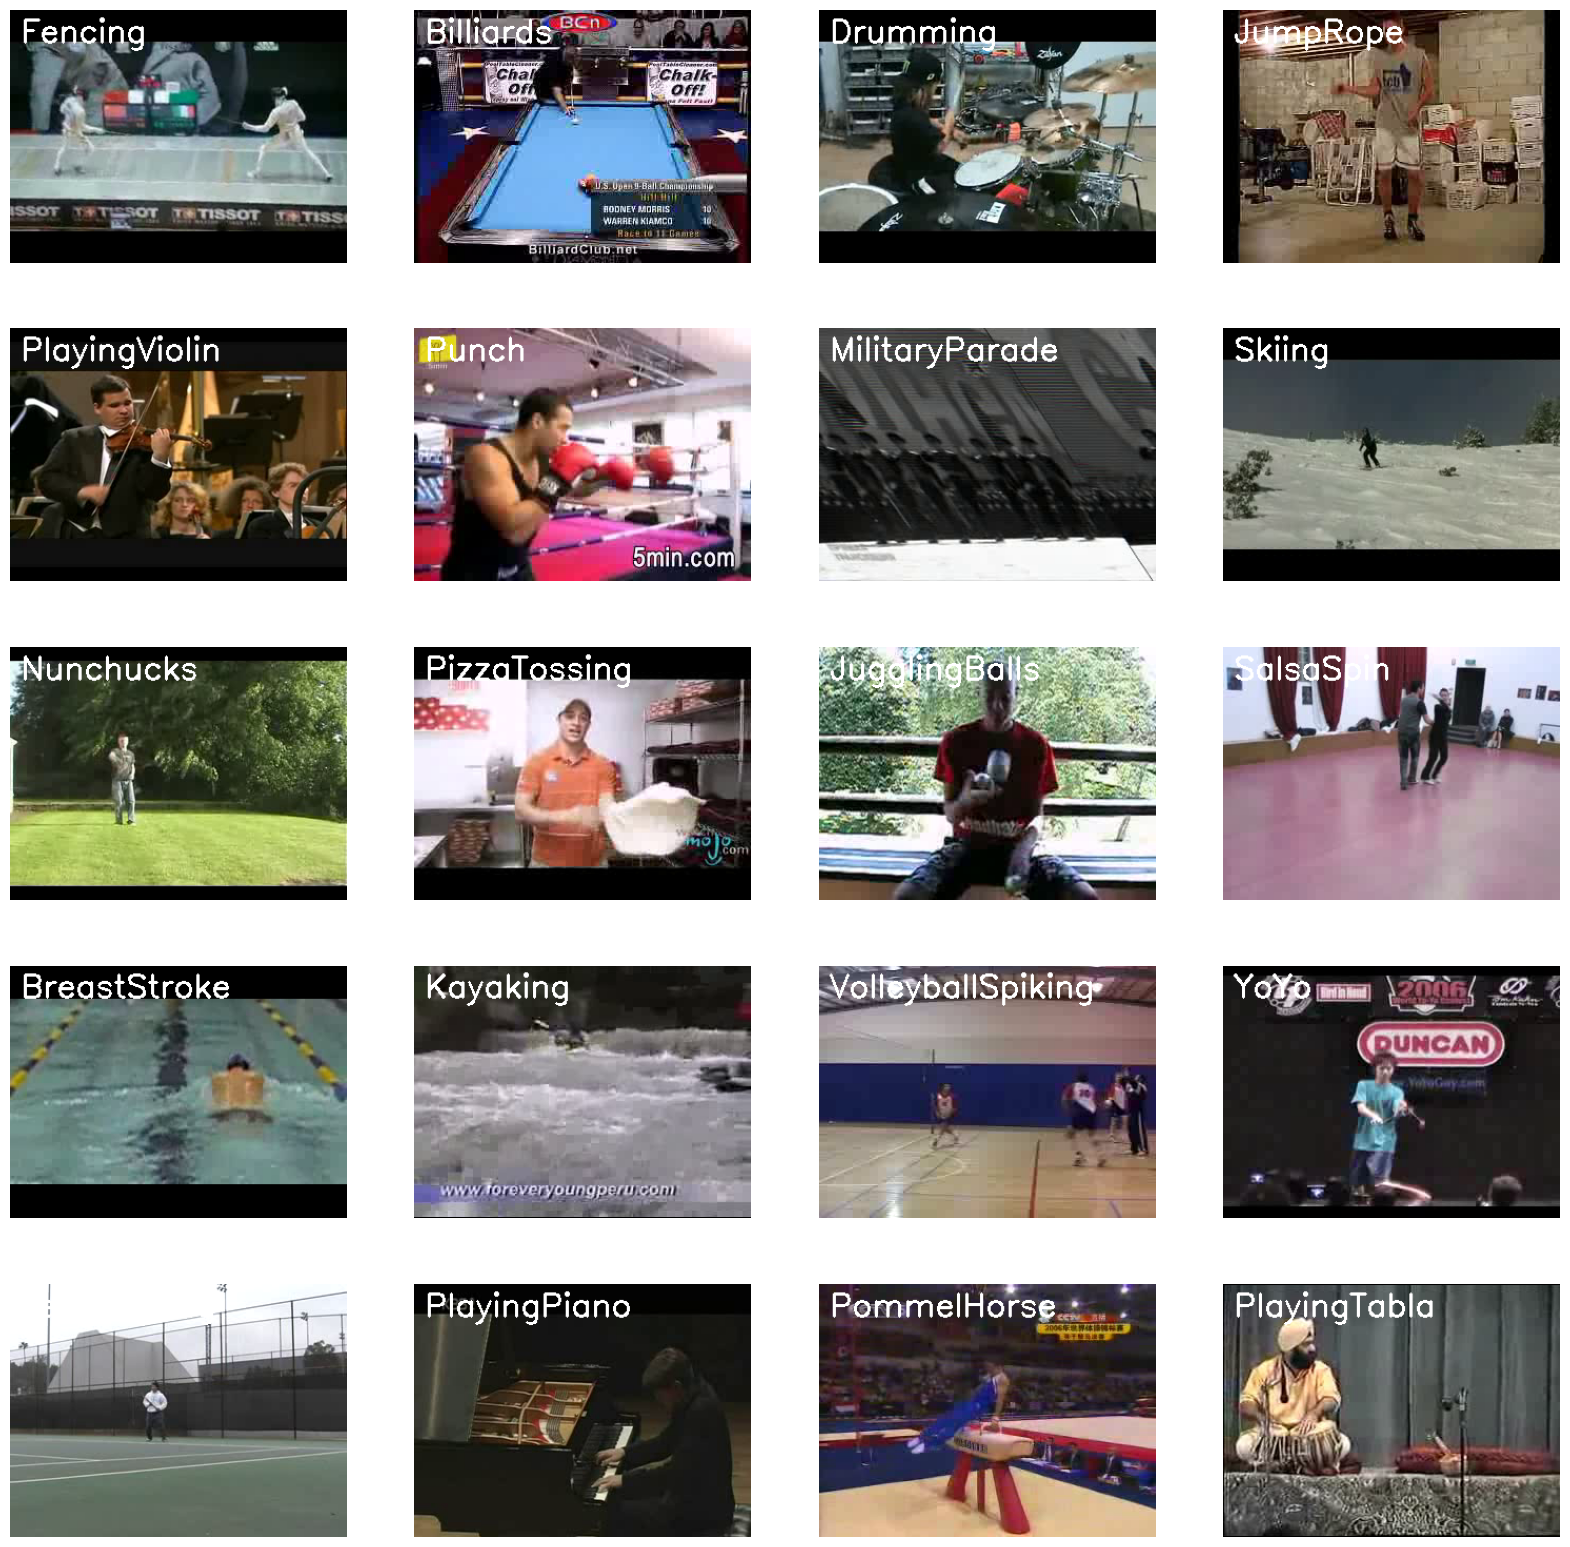

In [ ]:
plt.figure(figsize = (20, 20))

all_classes_names = os.listdir('UCF50')

random_range = random.sample(range(len(all_classes_names)), 20)
print(list(enumerate(random_range,1)))
for counter, random_index in enumerate(random_range, 1):

    selected_class_Name = all_classes_names[random_index]

    video_files_names_list = os.listdir(f'UCF50/{selected_class_Name}')

    selected_video_file_name = random.choice(video_files_names_list)

    video_reader = cv2.VideoCapture(f'UCF50/{selected_class_Name}/{selected_video_file_name}')

    _, bgr_frame = video_reader.read()

    video_reader.release()

    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

    cv2.putText(rgb_frame, selected_class_Name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    plt.subplot(5, 4, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')

In [ ]:
IMAGE_HEIGHT , IMAGE_WIDTH = 70, 70
SEQUENCE_LENGTH = 30
DATASET_DIR = "UCF50"
CLASSES_LIST = ["Punch","TaiChi","ThrowDiscus","Mixing"]


In [ ]:
def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

    for frame_counter in range(SEQUENCE_LENGTH):

        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()
        if not success:
            break
        sobelxy = cv2.Sobel(src=frame, ddepth=-1, dx=1, dy=1, ksize=5)
        resized_frame = cv2.resize(sobelxy, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255
        frames_list.append(normalized_frame)
    video_reader.release()
    return frames_list

In [ ]:
def create_dataset():
    features = []
    labels = []
    video_files_paths = []
    for class_index, class_name in enumerate(CLASSES_LIST):
        print(f'Extracting Data of Class: {class_name}')
        files_list = os.listdir(os.path.join(DATASET_DIR, class_name))
        i=0
        for file_name in files_list:
            if(i>100):
              break
            i+=1
            video_file_path = os.path.join(DATASET_DIR, class_name, file_name)
            frames = frames_extraction(video_file_path)
            if len(frames) == SEQUENCE_LENGTH:
                features.append(frames)
                labels.append(class_index)
                video_files_paths.append(video_file_path)
    features = np.asarray(features)
    labels = np.array(labels)
    return features,labels,video_files_paths


In [ ]:
features, labels, video_files_paths = create_dataset()

Extracting Data of Class: Punch
Extracting Data of Class: TaiChi
Extracting Data of Class: ThrowDiscus
Extracting Data of Class: Mixing


In [ ]:
print(features.shape)

(403, 30, 70, 70, 3)


In [ ]:
one_hot_encoded_labels = to_categorical(labels)

In [ ]:
seed_constant = 27
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.25, shuffle = True, random_state = seed_constant)

In [ ]:
def create_LRCN_model():
    model = Sequential()
    model.add(TimeDistributed(Conv2D(16, (2, 2), padding='same',activation = 'relu'),input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))

    model.add(TimeDistributed(Conv2D(32, (2, 2), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    model.add(TimeDistributed(Flatten()))

    model.add(LSTM(30))

    model.add(Dense(len(CLASSES_LIST), activation = 'softmax'))
    model.summary()
    return model

In [ ]:
LRCN_model = create_LRCN_model()
print("Model Created Successfully!")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_9 (TimeDis  (None, 30, 70, 70, 16)   208       
 tributed)                                                       
                                                                 
 time_distributed_10 (TimeDi  (None, 30, 17, 17, 16)   0         
 stributed)                                                      
                                                                 
 time_distributed_11 (TimeDi  (None, 30, 17, 17, 32)   2080      
 stributed)                                                      
                                                                 
 time_distributed_12 (TimeDi  (None, 30, 4, 4, 32)     0         
 stributed)                                                      
                                                                 
 time_distributed_13 (TimeDi  (None, 30, 4, 4, 64)    

In [ ]:
LRCN_model = keras.models.load_model('/content/LRCN_model___Date_Time_2023_04_18__12_17_26___Loss_0.7157217264175415___Accuracy_0.8415841460227966.h5')

In [ ]:
# callback = tf.keras.callbacks.LearningRateScheduler(scheduler)
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 30, mode = 'min', restore_best_weights = True)
LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])
LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 100, batch_size = 4 , shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])
# LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 100, batch_size = 4 , shuffle = True, validation_split = 0.2)

Epoch 1/100
61/61 [==============================] - 5s 34ms/step - loss: 1.3941 - accuracy: 0.2573 - val_loss: 1.3712 - val_accuracy: 0.2623
Epoch 2/100
61/61 [==============================] - 1s 14ms/step - loss: 1.2583 - accuracy: 0.4025 - val_loss: 1.1805 - val_accuracy: 0.4590
Epoch 3/100
61/61 [==============================] - 1s 15ms/step - loss: 1.0828 - accuracy: 0.5104 - val_loss: 1.1889 - val_accuracy: 0.3770
Epoch 4/100
61/61 [==============================] - 1s 15ms/step - loss: 1.0408 - accuracy: 0.5353 - val_loss: 1.0714 - val_accuracy: 0.6066
Epoch 5/100
61/61 [==============================] - 1s 18ms/step - loss: 1.0335 - accuracy: 0.5685 - val_loss: 0.9868 - val_accuracy: 0.6557
Epoch 6/100
61/61 [==============================] - 1s 18ms/step - loss: 0.8216 - accuracy: 0.6846 - val_loss: 0.8406 - val_accuracy: 0.6721
Epoch 7/100
61/61 [==============================] - 1s 15ms/step - loss: 0.7173 - accuracy: 0.6929 - val_loss: 0.9162 - val_accuracy: 0.6721
Epoch 

In [ ]:
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

4/4 [==============================] - 0s 26ms/step - loss: 0.7157 - accuracy: 0.8416


In [ ]:
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)
model_file_name = f'LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'
LRCN_model.save(model_file_name)

In [ ]:
LRCN_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, 30, 70, 70, 16)   208       
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  (None, 30, 17, 17, 16)   0         
 tributed)                                                       
                                                                 
 time_distributed_2 (TimeDis  (None, 30, 17, 17, 32)   2080      
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  (None, 30, 4, 4, 32)     0         
 tributed)                                                       
                                                                 
 time_distributed_4 (TimeDis  (None, 30, 4, 4, 64)     1

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]
    epochs = range(len(metric_value_1))
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)
    plt.title(str(plot_name))
    plt.legend()

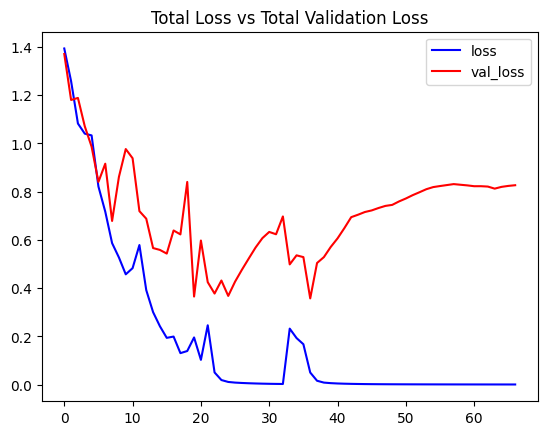

In [ ]:
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

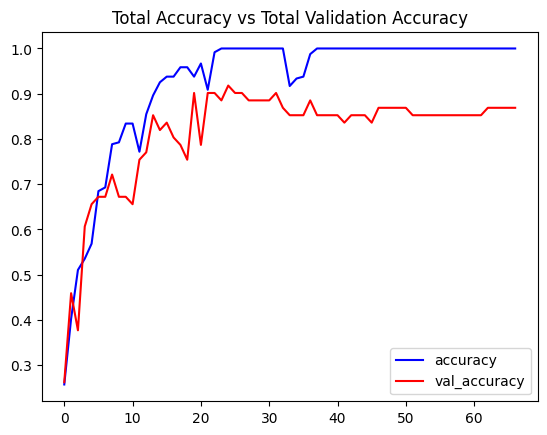

In [ ]:
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

In [ ]:
def download_youtube_videos(youtube_video_url, output_directory):
     link = youtube_video_url.replace(' ','')
     video= YouTube(link)
     title = video.title
    #  title= 1
     output_file_path = f'{output_directory}'
     video=video.streams.get_highest_resolution()
     video.download (output_file_path)
     return title

In [ ]:
test_videos_directory = '/content/test_videos'
os.makedirs(test_videos_directory, exist_ok = True)
video_title = download_youtube_videos("https://youtu.be/vcc0jNJwgJA", test_videos_directory)
print(video_title)
input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

In [ ]:
def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH):
    video_reader= cv2.VideoCapture(video_file_path)
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'),  video_reader.get(cv2.CAP_PROP_FPS), (original_video_width, original_video_height))
    frames_queue = deque(maxlen = SEQUENCE_LENGTH)
    predicted_class_name = ''
    if (video_reader.isOpened() == False):
      print("Error opening the video file")
    while video_reader.isOpened():
        ok, frame = video_reader.read()
        if not ok:
            # print("oops")
            break
        sobelxy = cv2.Sobel(src=frame, ddepth=-1, dx=1, dy=1, ksize=5)
        resized_frame = cv2.resize(sobelxy, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255
        frames_queue.append(normalized_frame)
        if len(frames_queue) == SEQUENCE_LENGTH:
            predicted_labels_probabilities=LRCN_model.predict(np.expand_dims(frames_queue, axis = 0))[0]
            predicted_label = np.argmax(predicted_labels_probabilities)
            predicted_class_name = CLASSES_LIST[predicted_label]
        cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        # print(frame.shape)
        video_writer.write(frame)
    video_reader.release()
    video_writer.release()

In [ ]:
output_video_file_path = f'{test_videos_directory}/{video_title}-Output-SeqLen{SEQUENCE_LENGTH}.mp4'
predict_on_video(input_video_file_path, output_video_file_path, SEQUENCE_LENGTH)
v=cv2.VideoCapture(output_video_file_path)
# print(int(v.get(cv2.CAP_PROP_FRAME_COUNT)))
# VideoFileClip(output_video_file_path, audio=False, target_resolution=(300,None)).ipython_display()

Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 60ms/step
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



t: 100%|█████████▉| 10035/10040 [01:18<00:00, 139.57it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.9/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/test_videos/Tai Chi vs Boxing-Output-SeqLen30.mp4, 479700 bytes wanted but 0 bytes read,at frame 10039/10040, at time 334.97/334.97 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+



Moviepy - Done !
Moviepy - video ready __temp__.mp4


ValueError: ignored

In [ ]:
def predict_single_action(video_file_path, SEQUENCE_LENGTH):
    video_reader = cv2.VideoCapture(video_file_path)
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames_list = []
    predicted_class_name = ''
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH),1)
    for frame_counter in range(SEQUENCE_LENGTH):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()
        if not success:
            print("oops!")
            break
        sobelxy = cv2.Sobel(src=frame, ddepth=-1, dx=1, dy=1, ksize=5)
        # sobel=cv2.Sobel(frame,-1,1,1,5)
        resized_frame = cv2.resize(sobelxy, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255
        frames_list.append(normalized_frame)
    # print(len(frames_list))
    predicted_labels_probabilities = LRCN_model.predict(np.expand_dims(frames_list, axis = 0))[0]
    # print("%")
    predicted_label = np.argmax(predicted_labels_probabilities)
    predicted_class_name = CLASSES_LIST[predicted_label]
    print(f'Action Predicted: {predicted_class_name}\nConfidence: {predicted_labels_probabilities[predicted_label]}')
    video_reader.release()

In [ ]:
video_title = download_youtube_videos('https://youtu.be/bJQFhV6CHHM', test_videos_directory)

input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

predict_single_action(input_video_file_path, SEQUENCE_LENGTH)

1/1 [==============================] - 0s 51ms/step
Action Predicted: ThrowDiscus
Confidence: 0.3381032347679138


In [ ]:
video_title = download_youtube_videos('https://youtu.be/ntP5FiTtVLw', test_videos_directory)

input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

predict_single_action(input_video_file_path, SEQUENCE_LENGTH)

1/1 [==============================] - 0s 51ms/step
Action Predicted: Punch
Confidence: 0.980781078338623


In [ ]:
video_title = download_youtube_videos('https://youtu.be/D2W605JFCTU', test_videos_directory)

input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

predict_single_action(input_video_file_path, SEQUENCE_LENGTH)

1/1 [==============================] - 0s 23ms/step
Action Predicted: TaiChi
Confidence: 0.9728910326957703


4/4 [==============================] - 0s 25ms/step


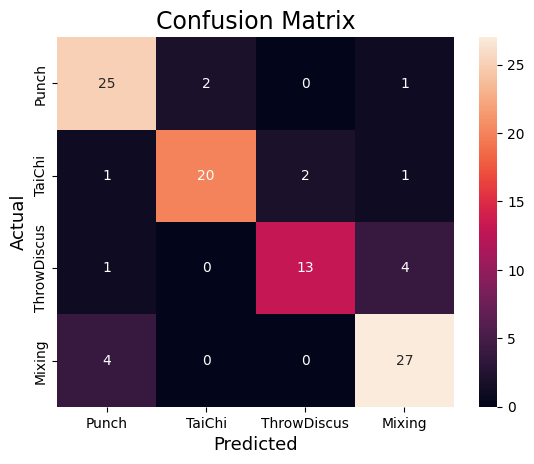

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def f(ll):
  a=[]
  for l in ll:
    if (l[0]==1. or l[0]==1):
      a.append(0)
    elif(l[1]==1.or l[1]==1):
      a.append(1)
    elif(l[2]==1. or l[2]==1):
      a.append(2)
    elif(l[3]==1. or l[3]==1):
      a.append(3)
    else:
      a.append(4)
  return a
# print(labels_test[0])
# print(labels_test.shape)
w1=f(labels_test)
m1=LRCN_model.predict(features_test)
w2=[]
for i in m1:
  w2.append(np.argmax(i))
# print(w2)
cm = confusion_matrix(w1,w2)
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=CLASSES_LIST,
            yticklabels=CLASSES_LIST)
plt.ylabel('Actual',fontsize=13)
plt.xlabel('Predicted',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()